# Semana 2 — Cadenas de Markov discretas: matriz de transición y ecuación de Chapman-Kolmogorov

**Curso:** Procesos Estocásticos · Ingeniería Industrial · Universidad EIA
**Bloque:** A — Procesos Estocásticos (Ross, cap. 4)
**Resultado de aprendizaje:** RA1 — *Modelar sistemas estocásticos discretos y continuos aplicando principios de probabilidad e ingeniería.*
**Tipo de notebook:** Contenido (no gestionado por nbgrader — todas las actividades de esta semana son formativas, sin nota).

---

**Objetivos de esta sesión:**

- **O1.** Formalizar la propiedad de Markov: qué significa exactamente que un proceso "no tenga memoria".
- **O2.** Construir e interpretar una matriz de transición como objeto matemático (matriz estocástica).
- **O3.** Aplicar la ecuación de Chapman-Kolmogorov para calcular probabilidades a varios pasos.
- **O4.** Representar una cadena de Markov como un grafo dirigido con `networkx`.

**Conexión con lo que viene:** esta misma semana, en el **Taller 01** (evaluado), vas a construir esta misma matriz de transición y vas a estimar su comportamiento de largo plazo *simulando* miles de trayectorias. Hoy construimos primero la teoría que explica **por qué** ese comportamiento existe — antes de que lo programes.

## 1. La propiedad de Markov — *(O1)*

En la Semana 1 dijimos, de forma informal, que una cadena de Markov "no recuerda" su pasado. Formalicemos eso.

> **Propiedad de Markov.** Un proceso $\{X_n, n \geq 0\}$ con espacio de estados discreto satisface la propiedad de Markov si, para todo $n$ y todos los estados posibles:
>
> $$P(X_{n+1} = j \mid X_n = i,\ X_{n-1} = i_{n-1},\ \ldots,\ X_0 = i_0) = P(X_{n+1} = j \mid X_n = i)$$

En palabras: la probabilidad de a dónde vas mañana, dado *todo* tu historial, es exactamente la misma que si solo conocieras **dónde estás hoy**. Todo el historial anterior a hoy es irrelevante para predecir mañana — no es que no importe la información, es que esa información ya está resumida por completo en tu estado actual.

Llamamos $p_{ij} = P(X_{n+1} = j \mid X_n = i)$ a la **probabilidad de transición** de $i$ a $j$ — y, propiedad clave de una cadena de Markov *homogénea* (la única que vamos a estudiar en este curso), $p_{ij}$ no depende de $n$: la regla de transición es la misma en cualquier momento del tiempo.

### Actividad 1 — ¿Es plausible la propiedad de Markov aquí? *(O1, formativa)*

Para cada escenario, decide si asumir la propiedad de Markov es razonable, y justifica en una frase.

**a)** El estado de una máquina (Operativa / Mantenimiento / Dañada), revisado cada turno — donde el estado de hoy ya refleja el desgaste acumulado.

**b)** El precio de una acción, si asumes que **la tendencia de los últimos 5 días** (no solo el precio de hoy) afecta el movimiento de mañana.

**c)** El resultado de lanzar una moneda cargada, donde cada lanzamiento es independiente de los anteriores.

In [1]:
# Escribe tu respuesta para cada escenario
respuesta_a = "..."
respuesta_b = "..."
respuesta_c = "..."


<details>
<summary><b>▶ Revelar solución y explicación</b></summary>

**a) Plausible.** Si el estado ("Operativa", "Mantenimiento", "Dañada") realmente resume toda la información relevante sobre el desgaste de la máquina, entonces conocer el estado de hoy es tan informativo como conocer todo el historial. Esta es, de hecho, la suposición que ya hicimos sin decirlo explícitamente en el Taller 01.

**b) No plausible, tal como está planteado.** Si el movimiento de mañana depende de la *tendencia* de los últimos 5 días, entonces el precio de hoy por sí solo no resume toda la información relevante — necesitarías conocer también los 4 días anteriores. **Truco importante:** esto no significa que sea imposible modelarlo como Markov — se puede redefinir el estado como "los últimos 5 precios" en vez de solo "el precio de hoy", y recuperar la propiedad de Markov sobre ese estado ampliado. Es una técnica común: cuando el proceso "parece" no ser Markov, muchas veces es porque el estado está mal definido, no porque el fenómeno sea inherentemente no-markoviano.

**c) Plausible (trivialmente).** Si los lanzamientos son independientes, el "estado anterior" no aporta ninguna información sobre el siguiente — la propiedad de Markov se cumple de la forma más simple posible, porque $P(X_{n+1}=j \mid X_n=i) = P(X_{n+1}=j)$ para cualquier $i$.

**Por qué importa el inciso (b):** es la trampa conceptual más común al aplicar cadenas de Markov en la práctica — antes de descartar el modelo, pregúntate si el estado está bien definido.
</details>

## 2. La matriz de transición como objeto matemático — *(O2)*

Esta es la misma matriz que vas a usar en el Taller 01 de esta semana. La construimos hoy en clase para entender **por qué tiene la forma que tiene**, antes de que la escribas tú en el taller.

> **Definición.** Para una cadena de Markov con $N$ estados, la matriz de transición $P$ es una matriz $N \times N$ donde $P_{ij} = p_{ij}$ es la probabilidad de pasar del estado $i$ al estado $j$ en un paso.

$P$ es una **matriz estocástica**: cumple dos propiedades que no son opcionales, son consecuencia directa de que cada fila es una distribución de probabilidad completa:

1. $P_{ij} \geq 0$ para todo $i, j$ (son probabilidades).
2. $\sum_j P_{ij} = 1$ para cada fila $i$ (desde cualquier estado, *algo* tiene que pasar — la fila agota todas las posibilidades).

In [2]:
import numpy as np

# El mismo ejemplo del Taller 01: Operativa (0), Mantenimiento (1), Dañada (2)
P = np.array([
    [0.90, 0.07, 0.03],
    [0.60, 0.35, 0.05],
    [0.10, 0.50, 0.40],
])

print("Matriz de transición P:")
print(P)
print()
print("Suma de cada fila (debe ser 1.0 en todas):", P.sum(axis=1))

Matriz de transición P:
[[0.9  0.07 0.03]
 [0.6  0.35 0.05]
 [0.1  0.5  0.4 ]]

Suma de cada fila (debe ser 1.0 en todas): [1. 1. 1.]


### Actividad 2 — Diagnosticar una matriz inválida *(O2, formativa)*

Un colega te envía esta matriz de transición para un sistema de 3 estados, pero algo está mal:

```
Q = [[0.5, 0.3, 0.1],
     [0.2, 0.6, 0.2],
     [0.4, 0.4, 0.4]]
```

Sin correr código, identifica **qué fila está mal** y **por qué** no puede ser una matriz de transición válida.

In [3]:
# Verifica tu diagnóstico con código
Q = np.array([
    [0.5, 0.3, 0.1],
    [0.2, 0.6, 0.2],
    [0.4, 0.4, 0.4],
])
print("Suma de cada fila:", Q.sum(axis=1))

Suma de cada fila: [0.9 1.  1.2]


<details>
<summary><b>▶ Revelar solución y explicación</b></summary>

**La fila 0 está mal:** suma $0.5+0.3+0.1 = 0.9$, no 1.0 — le falta 0.1 de probabilidad "perdida" en algún lado (quizás el colega olvidó una transición posible).

**La fila 2 también está mal:** suma $0.4+0.4+0.4=1.2$, se pasa de 1.0 — eso ni siquiera podría interpretarse como probabilidades válidas, alguna de esas cifras está mal capturada.

**Por qué importa:** este tipo de error es extremadamente común al construir matrices de transición a mano a partir de datos — es la primera verificación que deberías hacer siempre (`P.sum(axis=1)`) antes de usar una matriz para cualquier cálculo, exactamente lo que va a verificar el test automático del Ejercicio 1 del Taller 01, cuando lo hagas.
</details>

## 3. La ecuación de Chapman-Kolmogorov — *(O3)*

**La pregunta que responde:** si hoy la máquina está Operativa, ¿cuál es la probabilidad de que esté Dañada **en 2 turnos**, no en 1?

No es simplemente $p_{02}$ (esa es la probabilidad a *un* paso). Hay que considerar **todos los caminos posibles** de 2 pasos que llevan de Operativa a Dañada — y aquí es donde reconoces algo que ya usaste en la Semana 1: esto es, otra vez, la **ley de probabilidad total**, ahora aplicada paso a paso.

> **Ecuación de Chapman-Kolmogorov.** Sea $p_{ij}^{(n)} = P(X_n = j \mid X_0 = i)$ la probabilidad de ir de $i$ a $j$ en exactamente $n$ pasos. Entonces:
>
> $$p_{ij}^{(n+m)} = \sum_k p_{ik}^{(n)} \cdot p_{kj}^{(m)}$$

En palabras: para ir de $i$ a $j$ en $n+m$ pasos, primero llegas a *algún* estado intermedio $k$ en $n$ pasos, y de ahí a $j$ en los $m$ pasos restantes — sumando sobre todos los posibles $k$. Es exactamente la lógica de "condicionar sobre lo que puede pasar en el camino" que ya usaste en la Actividad 1 de la Semana 1.

**El resultado práctico, el que realmente vas a usar:** esta suma sobre todos los caminos intermedios es, exactamente, **multiplicación de matrices**. Por eso:

$$P^{(n)} = P^n \quad \text{(la matriz de transición elevada a la potencia } n\text{)}$$

No necesitas sumar caminos a mano — el álgebra de matrices lo hace por ti.

In [4]:
# Probabilidad de transición a 2 pasos: P^2
P2 = P @ P  # multiplicación de matrices, NO multiplicación elemento a elemento

print("P^2 =")
print(np.round(P2, 4))
print()
print(f"P(Dañada en 2 turnos | Operativa hoy) = P²[0,2] = {P2[0, 2]:.4f}")
print(f"Compara con un solo paso: P(Dañada mañana | Operativa hoy) = P[0,2] = {P[0, 2]}")

P^2 =
[[0.855  0.1025 0.0425]
 [0.755  0.1895 0.0555]
 [0.43   0.382  0.188 ]]

P(Dañada en 2 turnos | Operativa hoy) = P²[0,2] = 0.0425
Compara con un solo paso: P(Dañada mañana | Operativa hoy) = P[0,2] = 0.03


Nota algo importante en el resultado: la probabilidad de estar dañada en 2 pasos (≈4.25%) es más alta que en 1 paso (3%) — tiene sentido, hay más tiempo (y más caminos posibles, incluyendo pasar primero por Mantenimiento) para que algo salga mal. Pero **no es simplemente el doble** — la relación no es lineal, porque hay que ponderar cada camino por su propia probabilidad.

### Actividad 3 — Probabilidades a varios pasos *(O3, formativa)*

Usando `np.linalg.matrix_power(P, n)`, calcula la probabilidad de que la máquina esté **Operativa** dentro de **5 turnos**, dado que hoy está **Dañada**. Luego responde: ¿te sorprende el resultado? ¿Por qué sí o no, considerando las probabilidades de la fila "Dañada" en $P$?

In [5]:
from numpy.linalg import matrix_power

# YOUR CODE HERE
P5 = None
prob_operativa_en_5 = None

print("P(Operativa en 5 turnos | Dañada hoy) =", prob_operativa_en_5)

P(Operativa en 5 turnos | Dañada hoy) = None


<details>
<summary><b>▶ Revelar solución y explicación</b></summary>

```python
P5 = matrix_power(P, 5)
prob_operativa_en_5 = P5[2, 0]  # fila 2 = Dañada hoy, columna 0 = Operativa
```

**Resultado:** aproximadamente **0.79** (79%).

**Por qué no debería sorprenderte tanto:** aunque hoy esté Dañada, la fila "Dañada" de $P$ ya te decía que hay 10% de probabilidad de volver a Operativa en un solo paso, y "Mantenimiento" (60% de probabilidad desde Dañada) a su vez tiene 60% de probabilidad de llegar a Operativa. Con 5 turnos de margen, hay muchísimos caminos que llevan de vuelta a Operativa — el resultado alto es consistente con una máquina que, según este modelo, se recupera relativamente rápido de una falla.

**Conexión hacia adelante:** si sigues aumentando $n$ (pruébalo tú mismo: `matrix_power(P, 20)`), vas a notar que la probabilidad deja de depender de dónde empezaste — converge al mismo número sin importar el estado inicial. Eso **no es casualidad**, y tiene un nombre formal que vas a estudiar la próxima semana: la **distribución estacionaria**. Por ahora, solo obsérvalo.
</details>

## 4. Representando la cadena como un grafo — *(O4)*

Una matriz de transición es, matemáticamente, equivalente a un **grafo dirigido y ponderado**: cada estado es un nodo, y cada $p_{ij} > 0$ es una flecha de $i$ a $j$ con peso $p_{ij}$. Para sistemas con pocos estados (como el nuestro, con 3), verlo como grafo suele ser más intuitivo que leer la matriz cruda.

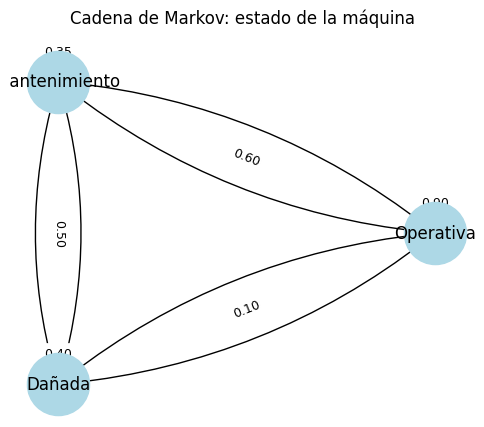

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

estados = ["Operativa", "Mantenimiento", "Dañada"]
G = nx.DiGraph()

for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino, weight=P[i, j])

pos = nx.circular_layout(G)
plt.figure(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2000)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, connectionstyle="arc3,rad=0.15", arrowsize=20)
etiquetas = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, font_size=9)
plt.title("Cadena de Markov: estado de la máquina")
plt.axis("off")
plt.show()

Fíjate en algo que el grafo hace muy visible y la matriz no tanto: cada estado tiene una flecha **hacia sí mismo** (un "self-loop") — la probabilidad de *quedarse* en el mismo estado (0.90, 0.35, 0.40) también es una transición válida, no un caso especial. Es fácil olvidar esto al pensar solo en la matriz.

## 5. Cierre y puente a la próxima semana

Hoy formalizamos la propiedad de Markov, la matriz de transición como objeto matemático, y la ecuación de Chapman-Kolmogorov para calcular probabilidades a varios pasos — la teoría que vas a necesitar en un momento, cuando arranquemos el Taller 01 al cierre de esta semana.

Notaste en la Actividad 3 que, a medida que aumentas el número de pasos, la probabilidad deja de depender del estado inicial. La próxima semana (S3) formalizamos exactamente ese fenómeno: **clasificación de estados** (¿todos los estados son "iguales" en la cadena, o hay diferencias estructurales importantes?) y **distribución estacionaria** — el comportamiento de largo plazo que ya viste aparecer, tanto en tus cálculos de hoy como en la simulación que vas a hacer en el Taller 01.

---
**Referencias de esta semana:** Ross, S. M. *Introduction to Probability Models*, cap. 4, secciones 4.1 (introducción a cadenas de Markov) y 4.2 (ecuaciones de Chapman-Kolmogorov).